## Projeto 1 - Análise Exploratória de Dados

Neste projeto, vamos abordar conceitos de análise exploratória de dados, essenciais para conhecermos melhor o conjunto de dados que estamos trabalhando.

O _dataset_ a ser examinado apresenta um exemplo prático de um problema de classificação, envolvendo a possibilidade de sobrevivência de passageiros do titanic com base em suas características.

Vamos iniciar carregando o dataset **titanic/train.csv** em um *DataFrame* do **pandas**.

---

In [ ]:
import pandas as pd

# Importar dados
dataset_path = "titanic/train.csv" 
titanic = pd.read_csv(dataset_path)

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


### Análise Univariada

Com o objetivo de verificar o conteúdo e a integridade do dataset, responda as seguintes perguntas.

1) Qual o número de features e instâncias?
2) Quais features são categóricas e quais são contínuas?
3) Há dados faltantes em algumas das features? Se sim, em quais?
4) Em qual das features há mais notavelmente a presença de outlier?
5) Há mais passageiros que sobreviveram, ou não? Justifique.
6) Qual a idade média dos passageiros?
7) Qual a classe mais comum em que os passageiros viajaram (Pclass)?

In [7]:
# Escreva aqui seu código para responder as perguntas acima

### Separação Treinamento/Teste

Para realizarmos análises exploratórias que utilizem o target para orientar decisões de modelagem, é necessário dividir o dataset nos conjuntos de treino e teste.

Desse modo, estamos garantindo que o modelo não tenha acesso indireto a informações do conjunto de teste, evitando _data leakage_.

In [24]:
### SEPARAÇÃO TREINAMENTO/TESTE ###

from sklearn.model_selection import train_test_split

titanic_train, titanic_test = train_test_split(titanic, test_size=0.2, random_state=42)

<Axes: xlabel='Age', ylabel='Fare'>

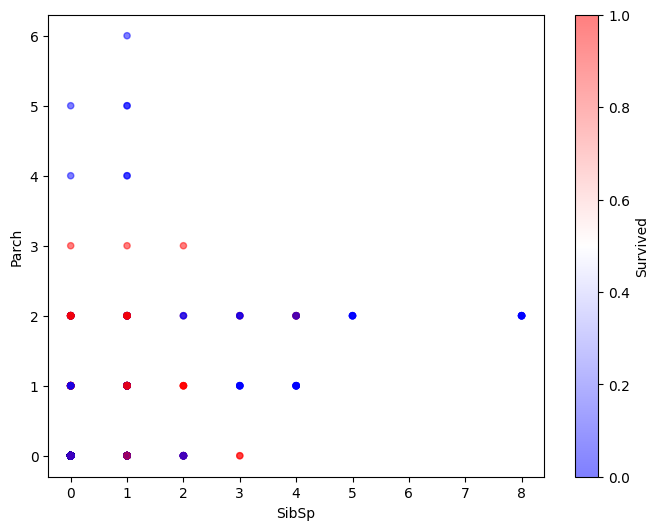

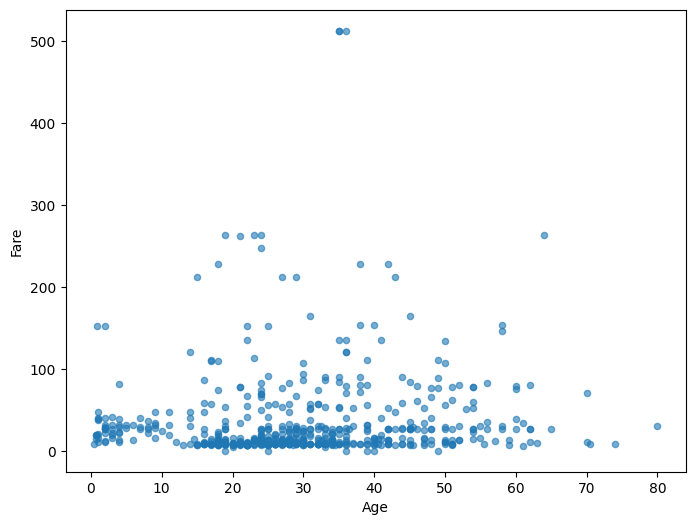

In [ ]:
# Escreva aqui seu código para responder as perguntas acima

### Análise Bivariada

1) Para as features numéricas, plote a matriz de correlação linear.
2) Qual feature apresenta menor correlação com o target? Faz sentido incluí-la no treinamento?
3) Qual feature apresenta maior correlação com o target? Esse dado garante que ela é a feature mais importante?
4) Realize o boxplot conjunto entre a feature _Fare_ (valor pago no ticket) e o target. O que pode ser observado?
6) Faça a tabela de contigência entre a feature _Sex_ e o target. Qual porcentagem de homens sobreviveu? E de mulheres?


Survived    0    1
Sex               
female     64  181
male      380   87


<Axes: title={'center': 'Fare'}, xlabel='Survived'>

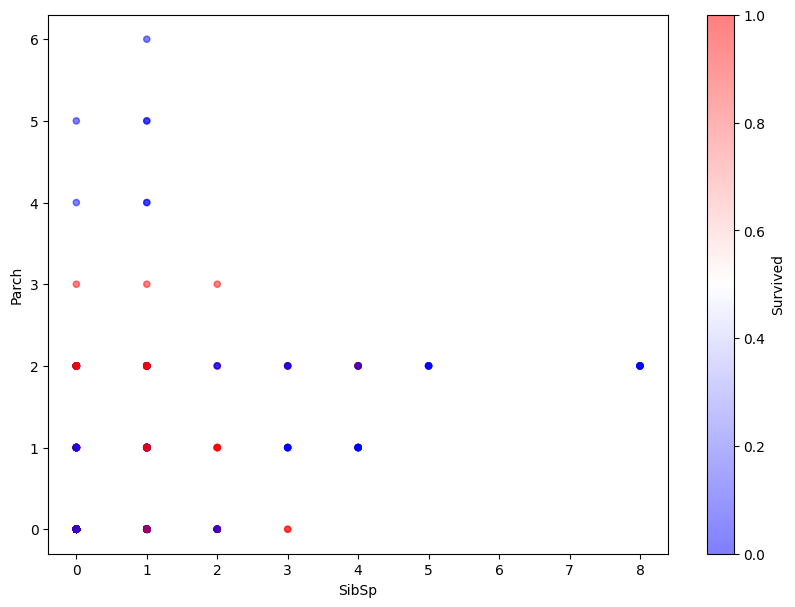

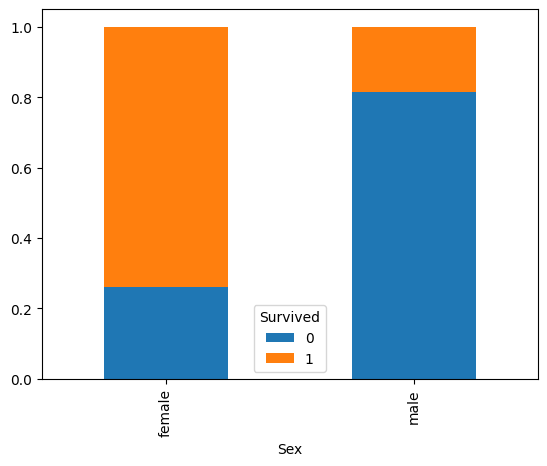

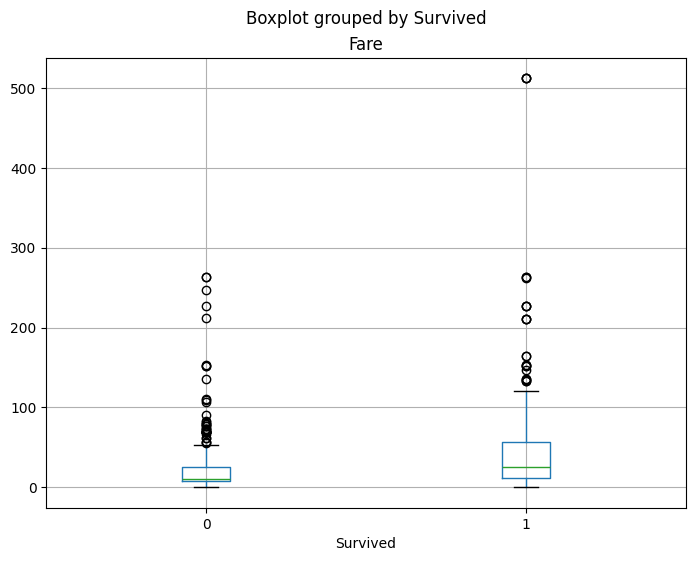

In [5]:
### ANÁLISE EXPLORATÓRIA NO CONJUNTO DE TREINAMENTO ###

# Scatter plots
titanic_train.plot(kind='scatter', x='SibSp', y='Parch', c='Survived', cmap='bwr', alpha=0.5, figsize=(10,7)) # Passageiros sozinhos e pasageiros em famílias mais numerosas tiveram menos chances de sobreviver.

# Tabela de contingência
print(pd.crosstab(titanic_train["Sex"], titanic_train["Survived"]))
pd.crosstab(titanic_train["Sex"], titanic_train["Survived"], normalize='index').plot(kind='bar', stacked=True) 
# A proporção de mulheres sobreviventes é muito maior que a de homens. Sexo pode ser um atributo importante para a predição.

# Box plots
titanic_train.boxplot(column='Fare', by='Survived', figsize=(8,6)) 
# Em média, quem pagou mais teve mais chances de sobreviver. Contudo, há uma quantidade razoável de outliers, o que pode dificultar a predição.